In [1]:
import os
from dataclasses import dataclass
from math import gcd
from typing import Optional

import matplotlib.pyplot as plt # Python package for ploting
import neurokit2 as nk # python package for physiological signal processing
import numpy as np
import scipy.signal # python package for signal processing 
from scipy.signal import butter, filtfilt

In [2]:
data = r'Data\S01L_stationary_ppg.npy'
if os.path.exists(data):
    ppg_data = np.load(data)
else:
    raise FileNotFoundError(f"{data} not found. cwd={os.getcwd()}")

In [3]:
print(ppg_data)

[[-0.0453813 ]
 [-0.05023229]
 [-0.05305367]
 ...
 [-0.04442972]
 [-0.0426171 ]
 [-0.03938758]]


In [4]:
print(ppg_data.shape)

(30720, 1)


 SamplingFrequency = 64Hz
 Duration =30720 % SamplingFrequency
 Duration = 480 sec ( 8min)

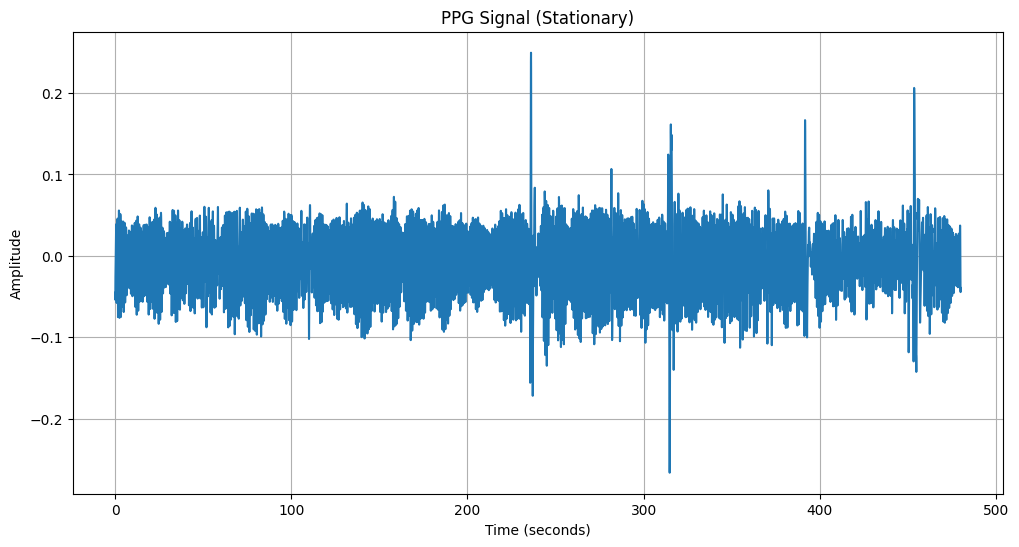

In [5]:
fs = 64  # Sampling frequency in Hz
time = np.arange(len(ppg_data)) / fs  # Time axis in seconds

plt.figure(figsize=(12, 6))
plt.plot(time, ppg_data)
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title('PPG Signal (Stationary)')
plt.grid(True)
plt.show()

In [6]:
import ipywidgets as widgets
from IPython.display import display

window_duration = 10  # seconds
samples_per_window = window_duration * fs
total_samples = len(ppg_data)

In [7]:
def plot_window(start_sample):
    end_sample = min(start_sample + samples_per_window, total_samples)
    plt.figure(figsize=(12, 6))
    plt.plot(time[start_sample:end_sample], ppg_data[start_sample:end_sample])
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.title(f'PPG Signal Window: {start_sample/fs:.1f}s to {end_sample/fs:.1f}s')
    plt.grid(True)
    plt.show()

In [8]:
max_start = total_samples - samples_per_window
if max_start < 0:
    max_start = 0
start_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=max_start,
    step=samples_per_window // 10,  # Step by 1 second for finer control
    description='Start Sample:',
    continuous_update=False
)


In [9]:
out = widgets.interactive_output(plot_window, {'start_sample': start_slider})
display(start_slider, out)

IntSlider(value=0, continuous_update=False, description='Start Sample:', max=30080, step=64)

Output()

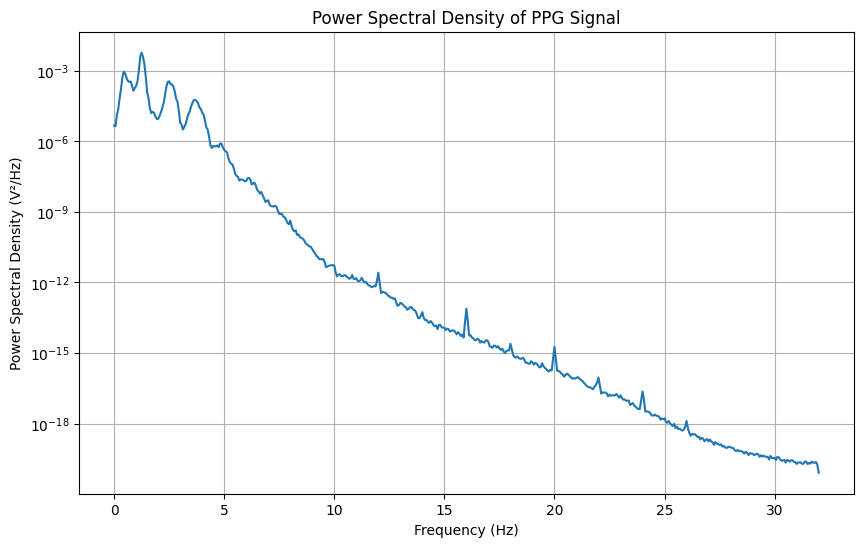

In [12]:
from scipy.signal import welch

# Compute PSD using Welch's method
frequencies, psd = welch(ppg_data.flatten(), fs=fs, nperseg=1024) # noverlap = nperseg // 2 , FFT to calculate amplitude for each freqeuncy squaring amplitude is power

# Plot the PSD
plt.figure(figsize=(10, 6))
plt.semilogy(frequencies, psd) # log scale 
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (V²/Hz)')
plt.title('Power Spectral Density of PPG Signal')
plt.grid(True)
plt.show()

Physiological freqeuncy range of Heart rate : ( 40bpm to 200bpm : Normal Range) -> 0.67 Hz to 3.34Hz 
PPG Frequency range : 0.5 to 4 Hz  Band pass filter
Upper Cutoff frequecy < Sampling freqeucy / 2 -> Otherwise Aliasing will take place ( Here fs/ 2 = 32Hz So no problem)

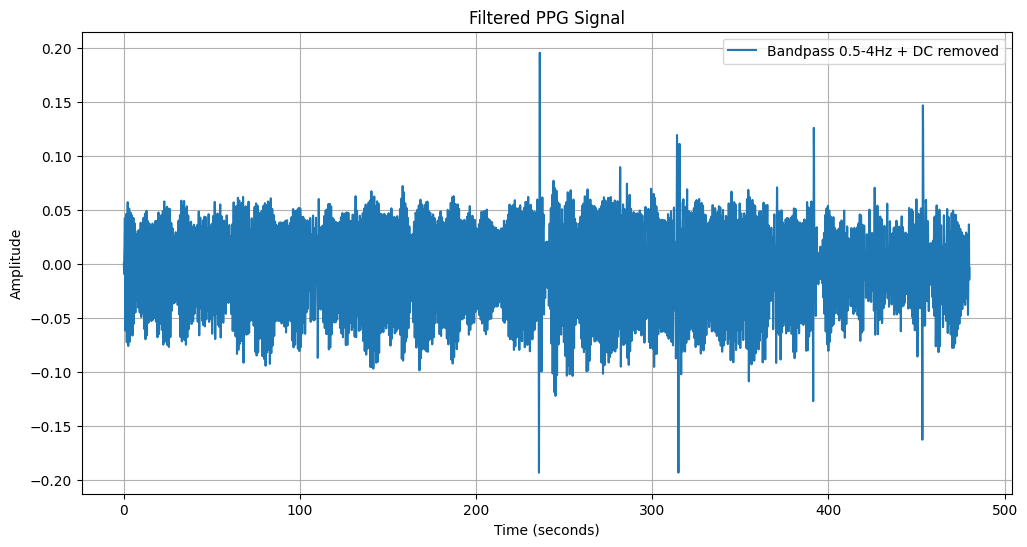

In [15]:
# Bandpass filter 0.5-4 Hz and remove DC component
lowcut = 0.5
highcut = 4.0
order = 4 # if signal is not too noisy by visualization can come up with order two but in most research based order 4 is used
nyq = 0.5 * fs
low = lowcut / nyq
high = highcut / nyq
b, a = butter(order, [low, high], btype='band')
ppg_bp = filtfilt(b, a, ppg_data.flatten())
ppg_bp = ppg_bp - np.mean(ppg_bp)  # ensure zero-mean (DC removal)

# Plot filtered signal
plt.figure(figsize=(12, 6))
plt.plot(time, ppg_bp, label='Bandpass 0.5-4Hz + DC removed')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title('Filtered PPG Signal')
plt.grid(True)
plt.legend()
plt.show()

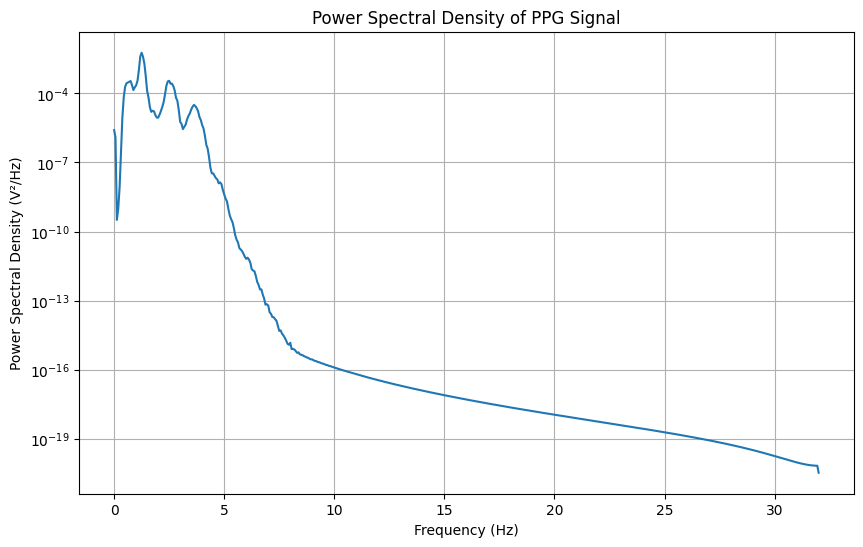

In [16]:
frequencies_bp, psd_bp = welch(ppg_bp.flatten(), fs=fs, nperseg=1024) # noverlap = nperseg // 2 , FFT to calculate amplitude for each freqeuncy squaring amplitude is power

# Plot the PSD
plt.figure(figsize=(10, 6))
plt.semilogy(frequencies_bp, psd_bp) # log scale 
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (V²/Hz)')
plt.title('Power Spectral Density of PPG Signal')
plt.grid(True)
plt.show()

In [17]:
# Segment the filtered signal into 10-second windows with 50% overlap
window_secs = 10
window_samples = window_secs * fs
overlap_samples = window_samples // 2
step = window_samples - overlap_samples

segments = []
start = 0
while start + window_samples <= len(ppg_bp):
    segments.append(ppg_bp[start:start + window_samples])
    start += step

print(f"Total samples: {len(ppg_bp)}")
print(f"Window samples: {window_samples}, Overlap samples: {overlap_samples}, Step: {step}")
print(f"Total segments: {len(segments)}")

# Convert to array of shape (n_segments, window_samples)
segments = np.vstack(segments) if segments else np.zeros((0, window_samples))


Total samples: 30720
Window samples: 640, Overlap samples: 320, Step: 320
Total segments: 95


Equation of the number of segments : ( Signal Length - Window Length ) / Overlap + 1 

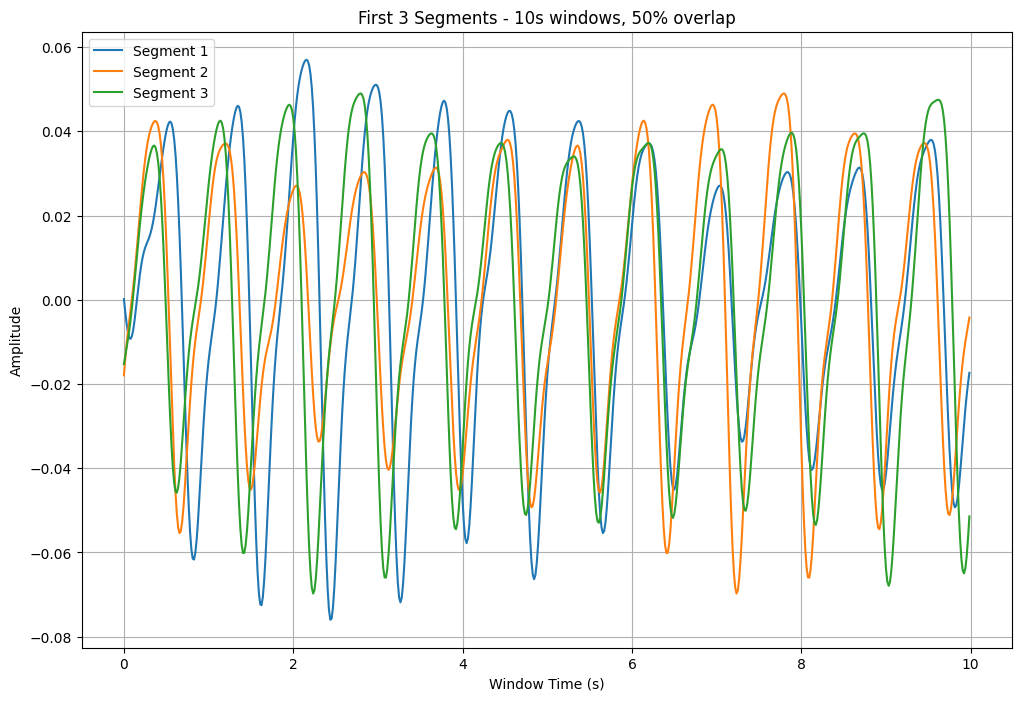

In [25]:
plt.figure(figsize=(12, 8))
for i in range(min(3, segments.shape[0])):
    seg_time = np.arange(window_samples) / fs
    plt.plot(seg_time, segments[i, :], label=f"Segment {i+1}")

plt.xlabel('Window Time (s)')
plt.ylabel('Amplitude')
plt.title('First 3 Segments - 10s windows, 50% overlap')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
from scipy.signal import find_peaks

# Detect peaks in each segment and store indices
segment_peaks = []
for i, seg in enumerate(segments):
    # limit with min distance and threshold to avoid noise picks
    peaks, properties = find_peaks(seg, distance=fs*0.3, prominence=np.std(seg)*0.5) # distance of 0.3s to avoid multiple peaks in one heartbeat, prominence to avoid noise peaks   
    segment_peaks.append((peaks, properties))
    #print(f"Segment {i+1}: {len(peaks)} peaks")


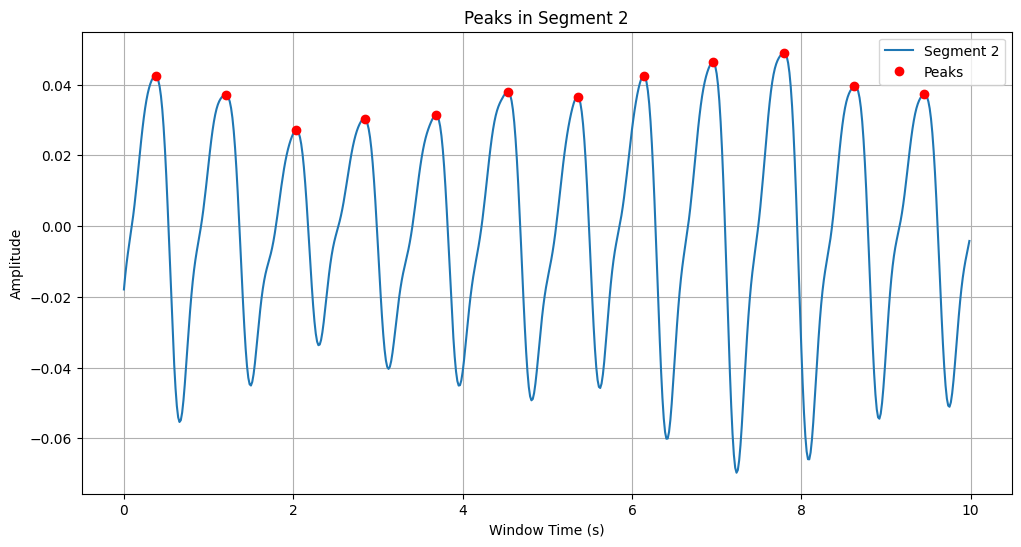

In [27]:
# Plot the peaks for a specified segment index (1-based)
segment_index = 2  # change this to inspect other segments
idx = segment_index - 1
if 0 <= idx < len(segments):
    seg = segments[idx]
    peaks, properties = segment_peaks[idx]
    seg_time = np.arange(window_samples) / fs

    plt.figure(figsize=(12, 6))
    plt.plot(seg_time, seg, label=f"Segment {segment_index}")
    plt.plot(seg_time[peaks], seg[peaks], 'ro', label='Peaks')
    plt.xlabel('Window Time (s)')
    plt.ylabel('Amplitude')
    plt.title(f'Peaks in Segment {segment_index}')
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print(f"Segment index {segment_index} out of range (1-{len(segments)})")

C:\Users\thamilezaia\AppData\Local\Temp\ipykernel_42944\2563490376.py:5: UserWarning: Only one segment is calculated since parameter NFFT (=640) >= signal length (=640).
  plt.specgram(segment_one, Fs=fs, NFFT=640, noverlap=320, cmap='viridis')


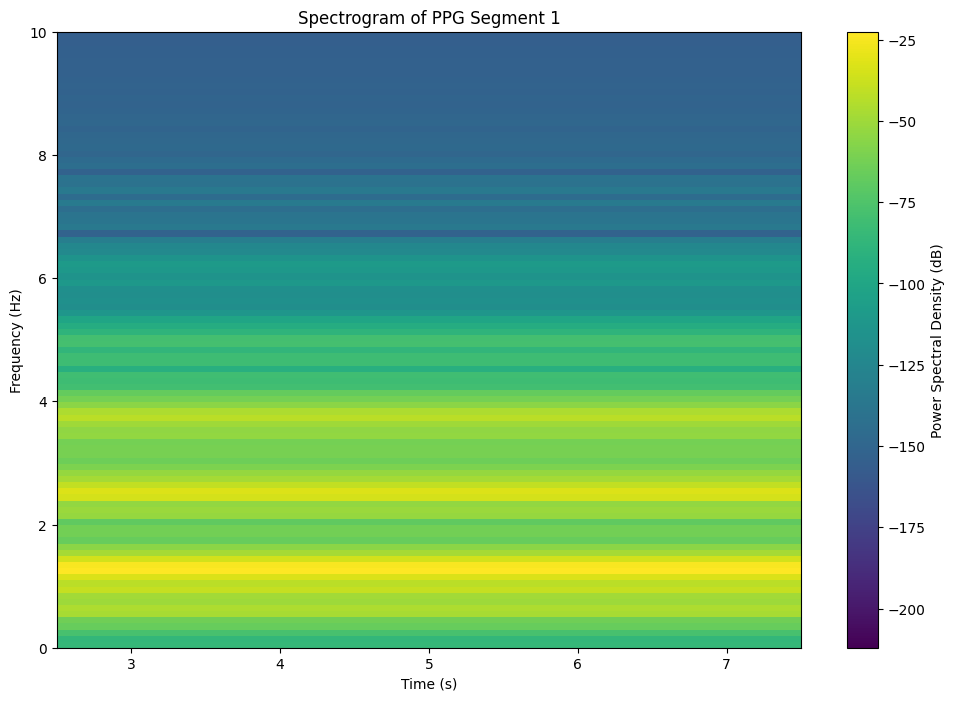

In [28]:
# Time-frequency spectrogram for segment one
segment_one = segments[0]  # First segment

plt.figure(figsize=(12, 8))
plt.specgram(segment_one, Fs=fs, NFFT=640, noverlap=320, cmap='viridis')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Spectrogram of PPG Segment 1')
plt.colorbar(label='Power Spectral Density (dB)')
plt.ylim(0, 10)  # Focus on physiological frequency range
plt.show()

HR = 60 * (beats / sec) -> BPM
   = 60 * ( 1 / gap time between two peaks )

Pan Topkins Algorithm can used to Estimate HR if PPG Signal is noisy (but limited predictable noise ( where we can model the stastical noise model)) : Less effective in heavy sports compared to Deep learning Architecture